# Bước 03-2: Đặc trưng metadata trạm
Dự án: Tốt nghiệp - Energy Forecasting - Nhóm thực hiện: The Outliers

Notebook này đọc các file từ bước 03-1 và thêm đặc trưng metadata (capacity, panel...).
Đây là đặc trưng tính theo từng dòng, không cần backward context.

Kết quả ghi ra `data/model/v3/03_2_features_spatial/`.

> ### Lưu ý về RAM trước khi chạy
>
> Notebook xử lý nhiều triệu dòng dữ liệu. Trước khi chạy: đóng kernel
> của các notebook khác trong VSCode. Mỗi kernel giữ vài GB và không tự nhả
> sau khi chạy xong.
>
> Notebook đã ghi file và `gc.collect()` ngay sau mỗi tập để không giữ
> nhiều DataFrame lớn cùng lúc.

## Bước 2. Import thư viện và khai báo tham số

In [10]:
import gc
import json
import os

import numpy as np
import pandas as pd

# ── Tham so dac trung ──
VERSION = 'v3'
EXPECTED_FREQ_MINUTES = 15
LAGS = (1, 4, 96)                    # 15 phut, 1 gio, 24 gio
ROLLING_WINDOWS = (4, 12, 96)        # 1 gio, 3 gio, 24 gio

CATEGORICAL_COLS = (
    'site_id', 'campus_name', 'location_name', 'site_metric', 'panel',
    'inverter', 'optimizers', 'weather_join_method',
    'weather_condition', 'weather_description',
)

# ── Ten cot ──
SITE_COL = 'site_id'
TIMESTAMP_COL = 'timestamp'
TARGET_COL = 'energy_generated_kwh'

# ── Ban do mua Nam ban cau ──
SOUTHERN_SEASON_MAP = {
    12: 'summer', 1: 'summer', 2: 'summer',
    3: 'autumn', 4: 'autumn', 5: 'autumn',
    6: 'winter', 7: 'winter', 8: 'winter',
    9: 'spring', 10: 'spring', 11: 'spring',
}
SEASON_CODE_MAP = {'summer': 0, 'autumn': 1, 'winter': 2, 'spring': 3}

INPUT_DIR = '../../data/model/v3/03_1_features_time'
OUTPUT_DIR = '../../data/model/v3/03_2_features_spatial'

print("Da import thu vien va khai bao tham so.")
print(f"- Doc tu  : {INPUT_DIR}")
print(f"- Ghi ra  : {OUTPUT_DIR}")

Da import thu vien va khai bao tham so.
- Doc tu  : ../../data/model/v3/03_1_features_time
- Ghi ra  : ../../data/model/v3/03_2_features_spatial


## Bước 3. Hàm đọc/ghi parquet

In [11]:
def require_columns(df, columns):
    """Bao loi som neu thieu cot bat buoc."""
    missing = [col for col in columns if col not in df.columns]
    if missing:
        raise KeyError(f"Missing required columns: {missing}")


def read_parquet(path):
    """Doc parquet, kiem tra cot bat buoc, ep kieu timestamp va sap xep."""
    df = pd.read_parquet(path)
    require_columns(df, [TIMESTAMP_COL, SITE_COL, TARGET_COL])
    df[TIMESTAMP_COL] = pd.to_datetime(df[TIMESTAMP_COL], errors='coerce')
    return df.sort_values([SITE_COL, TIMESTAMP_COL]).reset_index(drop=True)


def write_parquet(df, path):
    """Ghi parquet, tu tao thu muc neu chua co."""
    os.makedirs(os.path.dirname(path), exist_ok=True)
    df.to_parquet(path, index=False)
    return path


print("Da dinh nghia require_columns, read_parquet, write_parquet.")

Da dinh nghia require_columns, read_parquet, write_parquet.


## Bước 4. Đặc trưng metadata trạm

Chỉ tạo cột số và cờ thiếu. **Không** mã hóa categorical ở đây — việc đó
làm ở bước 03-3, để bảng mã được fit trên tập train rồi mới áp cho val/test.

In [12]:
def add_metadata_features(df):
    """Tao dac trung metadata dang so va co thieu du lieu.

    Ma hoa categorical duoc xu ly SAU khi sinh dac trung theo tung split, de bang ma
    fit tren train/development duoc dung lai cho val/test. KHONG goi cat.codes o day
    vi se gan ma khong nhat quan giua cac fold.
    """
    out = df.copy()

    for col in ('capacity_kw', 'number_of_panels'):
        if col in out.columns:
            out[f'{col}_missing_flag'] = out[col].isna().astype('int8')

    if {'capacity_kw', 'number_of_panels'}.issubset(out.columns):
        out['capacity_per_panel'] = out['capacity_kw'] / out['number_of_panels']
        out.loc[
            ~np.isfinite(out['capacity_per_panel']),
            'capacity_per_panel',
        ] = np.nan

    return out


print("Da dinh nghia add_metadata_features.")

Da dinh nghia add_metadata_features.


## Bước 5. Thêm đặc trưng metadata cho 4 tập chính

In [13]:
main_files = [
    (f'{VERSION}_development_time.parquet', f'{VERSION}_development_spatial.parquet'),
    (f'{VERSION}_test_time.parquet', f'{VERSION}_test_spatial.parquet'),
    (f'{VERSION}_train_time.parquet', f'{VERSION}_train_spatial.parquet'),
    (f'{VERSION}_val_time.parquet', f'{VERSION}_val_spatial.parquet'),
]

for in_name, out_name in main_files:
    df = read_parquet(f'{INPUT_DIR}/{in_name}')
    df = add_metadata_features(df)
    write_parquet(df, f'{OUTPUT_DIR}/{out_name}')
    print(f"- {out_name}: {len(df)} dong x {df.shape[1]} cot")
    del df
    gc.collect()

print(f"\nDa ghi {len(main_files)} file dac trung spatial chinh.")

- v3_development_spatial.parquet: 2273970 dong x 106 cot
- v3_test_spatial.parquet: 510468 dong x 107 cot
- v3_train_spatial.parquet: 1791894 dong x 107 cot
- v3_val_spatial.parquet: 482076 dong x 107 cot

Da ghi 4 file dac trung spatial chinh.


## Bước 6. Thêm đặc trưng metadata cho 5 fold

In [14]:
folds_in = f'{INPUT_DIR}/time_series_folds'
folds_out = f'{OUTPUT_DIR}/time_series_folds'
fold_files = sorted(p for p in os.listdir(folds_in) if p.endswith('_time.parquet'))

for fname in fold_files:
    out_name = fname.replace('_time.parquet', '_spatial.parquet')
    df = read_parquet(f'{folds_in}/{fname}')
    df = add_metadata_features(df)
    write_parquet(df, f'{folds_out}/{out_name}')
    print(f"- {out_name}: {len(df)} dong x {df.shape[1]} cot")
    del df
    gc.collect()

print(f"\nDa ghi {len(fold_files)} file dac trung fold spatial.")

- fold_1_train_spatial.parquet: 132523 dong x 108 cot
- fold_1_val_spatial.parquet: 289097 dong x 108 cot
- fold_2_train_spatial.parquet: 421620 dong x 108 cot
- fold_2_val_spatial.parquet: 417729 dong x 108 cot
- fold_3_train_spatial.parquet: 839349 dong x 108 cot
- fold_3_val_spatial.parquet: 470469 dong x 108 cot
- fold_4_train_spatial.parquet: 1309818 dong x 108 cot
- fold_4_val_spatial.parquet: 482076 dong x 108 cot
- fold_5_train_spatial.parquet: 1791894 dong x 108 cot
- fold_5_val_spatial.parquet: 482076 dong x 108 cot

Da ghi 10 file dac trung fold spatial.


## Bước 7. Phân tích & Trực quan hóa Đặc trưng Metadata (Spatial Features)

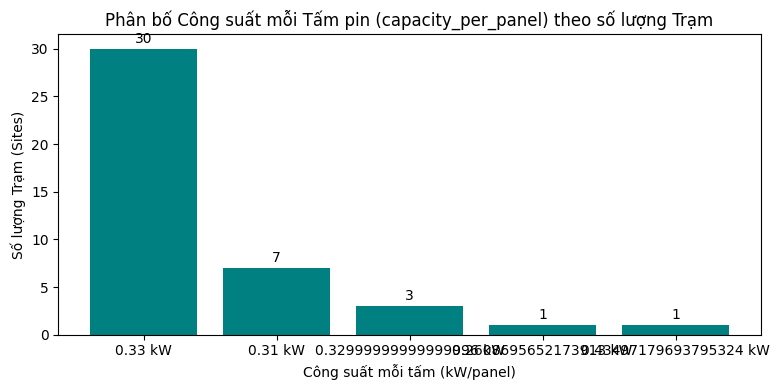

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

df_spatial = read_parquet(f'{OUTPUT_DIR}/{VERSION}_train_spatial.parquet')

if 'capacity_per_panel' in df_spatial.columns:
    cap_counts = df_spatial.groupby('site_id')['capacity_per_panel'].first().value_counts().reset_index()
    cap_counts.columns = ['capacity_per_panel', 'num_sites']
    
    plt.figure(figsize=(8, 4))
    bars = plt.bar(cap_counts['capacity_per_panel'].astype(str) + ' kW', cap_counts['num_sites'], color='teal')
    plt.title("Phân bố Công suất mỗi Tấm pin (capacity_per_panel) theo số lượng Trạm")
    plt.xlabel("Công suất mỗi tấm (kW/panel)")
    plt.ylabel("Số lượng Trạm (Sites)")
    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2.0, yval + 0.3, int(yval), ha='center', va='bottom')
    plt.tight_layout()
    plt.show()

### Nhận xét về Đặc trưng Spatial (Metadata):
- Đặc trưng `capacity_per_panel` chỉ có 4 giá trị rời rạc gần như hằng số trên toàn hệ thống (33 trạm có giá trị ~0.330 kW, 7 trạm có giá trị ~0.310 kW, 1 trạm 0.435 kW, 1 trạm 0.261 kW).
- Việc mã hóa các thuộc tính phân loại (`site_id_enc`, `campus_name_enc`) được thực hiện đồng bộ ở bước 03-3 để đảm bảo fit mã hóa trên tập train mà không gây rò rỉ dữ liệu.

## Bước 8. Hoàn tất

In [16]:
print("Hoàn tất bước 03-2: Đặc trưng metadata trạm.")

Hoàn tất bước 03-2: Đặc trưng metadata trạm.
